In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '../'))

In [3]:
import warnings

import json
from numpy import random
from model.optimization import create_study, ObjectiveSuggestion, SuggestionValueType, eval_model
from model.dataset import get_dataframe
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingClassifier

DEFAULT_RANDOM_SEED = 774
random.mtrand._rand.seed(DEFAULT_RANDOM_SEED)
warnings.filterwarnings("ignore")

In [8]:
def run_tests(category: str):
  train_data = get_dataframe(category=category, dataset="train")
  genes = json.loads(open(f"../../preprocessed/{category}/one_vs_all_gene_set.json").readline())
  print(f"Total chosen genes: {len(genes)}")

  _, model, _ = create_study(
    name=f"one_vs_all_gene_set",
    model_factory=lambda **kwargs: HistGradientBoostingClassifier(**kwargs, max_iter=1000, class_weight="balanced"),
    custom_dataset=(train_data[genes], train_data["subtype"]),
    suggestions=[
      ObjectiveSuggestion(
        value_type=SuggestionValueType.INT,
        param="max_depth",
        param_range=(1, 100)
      ),
      ObjectiveSuggestion(
        value_type=SuggestionValueType.FLOAT,
        param="max_features",
        param_range=(1e-3, 1),
        is_log=True
      ),
      ObjectiveSuggestion(
        value_type=SuggestionValueType.FLOAT,
        param="learning_rate",
        param_range=(1e-3, 1),
        is_log=True
      ),
      ObjectiveSuggestion(
        value_type=SuggestionValueType.FLOAT,
        param="l2_regularization",
        param_range=(1e-5, 1),
        is_log=True
      )
    ],
    report_test_results=False,
    trials=250
  )

  test_data = get_dataframe(category=category, dataset="test")
  return eval_model(model, dataset=(test_data[genes], test_data["subtype"]), report=True)

[I 2026-03-26 16:49:38,863] Using an existing study with name 'one_vs_all_gene_set' instead of creating a new one.


Total chosen genes: 92


[I 2026-03-26 16:49:49,621] Trial 100 finished with value: 0.8818613578196798 and parameters: {'max_depth': 16, 'max_features': 0.034384337698040474, 'learning_rate': 0.04688228693185525, 'l2_regularization': 3.216104993765168e-05}. Best is trial 88 with value: 0.9011022015873978.
[I 2026-03-26 16:49:50,568] Trial 103 finished with value: 0.8952144268370228 and parameters: {'max_depth': 16, 'max_features': 0.037713589847009406, 'learning_rate': 0.0017978736094936994, 'l2_regularization': 3.019563930718226e-05}. Best is trial 88 with value: 0.9011022015873978.
[I 2026-03-26 16:49:50,653] Trial 104 finished with value: 0.8943158395568567 and parameters: {'max_depth': 15, 'max_features': 0.03444255485464471, 'learning_rate': 0.0019236492142335304, 'l2_regularization': 3.758009383817279e-05}. Best is trial 88 with value: 0.9011022015873978.
[I 2026-03-26 16:49:55,805] Trial 107 finished with value: 0.8680674511258349 and parameters: {'max_depth': 17, 'max_features': 0.035605997056749626, '

   f1_weighted  f1_macro  recall_micro  balanced_accuracy  accuracy
0     0.877897  0.849756      0.877907           0.845367  0.877907


<Axes: >

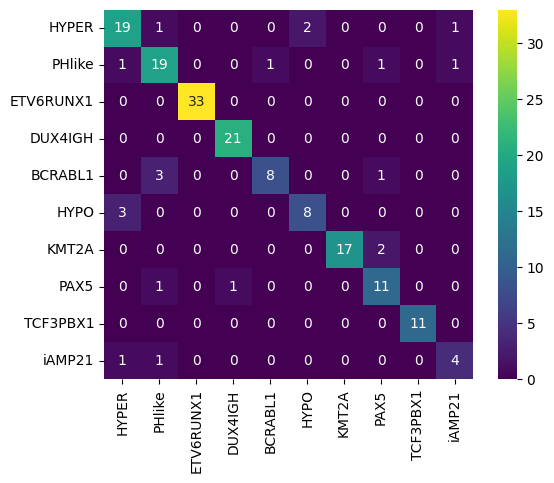

Exception ignored in: <function ResourceTracker.__del__ at 0x10475ac00>
Traceback (most recent call last):
  File "/Users/igor.mandello/.pyenv/versions/3.12.11/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/igor.mandello/.pyenv/versions/3.12.11/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/igor.mandello/.pyenv/versions/3.12.11/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107c4ac00>
Traceback (most recent call last):
  File "/Users/igor.mandello/.pyenv/versions/3.12.11/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/igor.mandello/

In [9]:
results = run_tests(category="min_tpm_5")
# fig, ax = plt.subplots(figsize=(12,10))
# sns.set(font_scale=1)
# ax.tick_params(labelsize=12)
sns.heatmap(results.confusion_matrix.confusion_matrix, annot=True, square=True, cmap="viridis", xticklabels=results.confusion_matrix.display_labels, yticklabels=results.confusion_matrix.display_labels)